# Train new Anisotropy model with GPR

Requires environment defined in /environment.yml

## Settings

In [68]:
# using IPython to autoreload modules when they are edited
%load_ext autoreload
%autoreload 2

BASE_PATH: /home/wager/projects/PUBLICATION/magnetic-uncertainty
DATA_PATH: /home/wager/projects/PUBLICATION/magnetic-uncertainty/data
MODEL_PATH: /home/wager/projects/PUBLICATION/magnetic-uncertainty/models
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import numpy as np
import random
import joblib
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel, WhiteKernel
from evaluation.residual import plot_cv_predictions_color_std
from evaluation.confidence import plot_confidence
from util import load_experimental, get_timestamp_as_string, DATA_PATH, MODEL_PATH
print('Imports OK')

Imports OK


In [70]:
TS = get_timestamp_as_string()
print(f"Timestamp: {TS}")
symbol = r"$\mu_0H_\mathrm{a}$"
MODEL_SAVE_PATH = MODEL_PATH / "Ha_gpr" / TS
MODEL_SAVE_PATH.mkdir(parents=True, exist_ok=True)
SEED = 123
np.random.seed(SEED)
random.seed(SEED)

Timestamp: 2026-01-19__20-00-43


# Train new model 

## Get data

In [71]:
# Load experimental data
df = load_experimental(file_name="2025-06-05_physical_properties.csv", dir_name=DATA_PATH)
print(f"loaded initial data with shape: {df.shape}")

Load data from '2025-06-05_physical_properties.csv'
No features provided for duplicate removal. Using default features: ['Nd', 'Ce', 'La', 'Pr', 'Y', 'Tb', 'Dy', 'Fe', 'Co', 'Ni', 'B', 'C', 'temp']
Dropped 40 duplicates.
Applied sphere transform to elemental features.
Scaled 'temp' feature to 'temp_s' by dividing by max temp.
loaded initial data with shape: (1479, 39)


In [72]:
# Select scaled data
features_physics = ['Nd_s', 'Ce_s', 'La_s', 'Pr_s', 'Y_s', 'Tb_s', 'Dy_s', 'Fe_s', 'Co_s', 'Ni_s', 'B_s', 'C_s', "temp_s"]
df_ha = df[features_physics + ["Ha"]].copy()
# Split data into features and target
X = df_ha.drop("Ha", axis=1)
y = df_ha["Ha"]

## Create model

In [73]:
# Custom GaussianProcessRegressor that always predicts with std
class CustomGPR(GaussianProcessRegressor):
    def predict(self, X, return_std=True, return_cov=False):
        return super().predict(X, return_std=return_std, return_cov=return_cov)

### Fit model

In [74]:
# Define a Gaussian Process Regressor
kernel = ConstantKernel() * Matern(length_scale=1.0, nu=1.5) + WhiteKernel(
    noise_level=1, 
    noise_level_bounds=(1e-5, 1e1)
)
regressor = CustomGPR(
    kernel=kernel, 
    n_restarts_optimizer=2,
    normalize_y=False, 
    random_state=SEED
)

In [75]:
# Fit the model
print("fitting regressor for prediction ...")
regressor.fit(X, y.values)

fitting regressor for prediction ...


CustomGPR(kernel=1**2 * Matern(length_scale=1, nu=1.5) + WhiteKernel(noise_level=1),
          n_restarts_optimizer=2, random_state=123)

### Write model architecture to file and output 

In [76]:
# Write model summary to file for sklearn GaussianProcessRegressor
model_summary_path = MODEL_SAVE_PATH / "ha_model_summary.txt"

summary_lines = [
    "GaussianProcessRegressor Summary",
    "*" * 80,
    f"Initial Kernel: {regressor.kernel}",  # before fitting
]

# After fitting, include optimized kernel and LML
if hasattr(regressor, "kernel_"):
    summary_lines.append(f"Optimized Kernel: {regressor.kernel_}")
    summary_lines.append(f"Log-Marginal Likelihood: {regressor.log_marginal_likelihood_value_:.3f}")

summary_lines.extend([
    f"Optimizer: {regressor.optimizer}",
    f"Alpha: {regressor.alpha}",
    f"Normalize_y: {regressor.normalize_y}",
    f"Number of restarts: {regressor.n_restarts_optimizer}",
])

if hasattr(regressor, "X_train_"):
    summary_lines.append(f"Training samples: {regressor.X_train_.shape[0]}")
    summary_lines.append(f"Number of features: {regressor.X_train_.shape[1]}")

summary = "\n".join(summary_lines)

# Print and save to file
print(summary)
with open(model_summary_path, "w") as f:
    f.write(summary)

GaussianProcessRegressor Summary
********************************************************************************
Initial Kernel: 1**2 * Matern(length_scale=1, nu=1.5) + WhiteKernel(noise_level=1)
Optimized Kernel: 13.6**2 * Matern(length_scale=2.63, nu=1.5) + WhiteKernel(noise_level=0.0977)
Log-Marginal Likelihood: -1012.271
Optimizer: fmin_l_bfgs_b
Alpha: 1e-10
Normalize_y: False
Number of restarts: 2
Training samples: 1479
Number of features: 13


### Save model to disk

In [77]:
# Define save path
model_path = MODEL_SAVE_PATH / "ha_model.pkl"
# Save the trained regressor
joblib.dump(regressor, model_path)
print(f"Model saved to {model_path}")

Model saved to /home/wager/projects/PUBLICATION/magnetic-uncertainty/models/Ha_gpr/2026-01-19__20-00-43/ha_model.pkl


# Evaluation

## Prediction accuracy

### Perform 5-fold cross validation

In [78]:
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=SEED)

model_name = "Ha_gpr"
y_pred_cv_all = np.zeros_like(y, dtype=float)
y_std_cv_all = np.zeros_like(y, dtype=float)

mae_scores = []
mse_scores = []
r2_scores = []

for i, (train_idx, val_idx) in enumerate(kf.split(X)):
    print(f"\nFitting for cross-validation split {i+1}/{n_splits} ...\n")
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # Clone regressor for each fold
    model = CustomGPR(
        kernel=regressor.kernel, 
        n_restarts_optimizer=regressor.n_restarts_optimizer,
        normalize_y=regressor.normalize_y)

    model.fit(X_train, y_train)
    y_pred_fold, y_std_fold = model.predict(X_val, return_std=True)

    y_pred_cv_all[val_idx] = y_pred_fold
    y_std_cv_all[val_idx] = y_std_fold

    # Compute metrics for this fold
    mae_scores.append(mean_absolute_error(y_val, y_pred_fold))
    mse_scores.append(mean_squared_error(y_val, y_pred_fold))
    r2_scores.append(r2_score(y_val, y_pred_fold))

# Compute averages
mae_cv_avg = np.mean(mae_scores)
mse_cv_avg = np.mean(mse_scores)
r2_cv_avg = np.mean(r2_scores)

print(f"{model_name} - MAE: {mae_cv_avg:.4f}, MSE: {mse_cv_avg:.4f}, R2: {r2_cv_avg:.4f}")
print(f"{model_name} - mean predictive std: {y_std_cv_all.mean():.4f}")


Fitting for cross-validation split 1/5 ...


Fitting for cross-validation split 2/5 ...


Fitting for cross-validation split 3/5 ...


Fitting for cross-validation split 4/5 ...


Fitting for cross-validation split 5/5 ...

Ha_gpr - MAE: 0.2482, MSE: 0.1554, R2: 0.9736
Ha_gpr - mean predictive std: 0.4054


### Plot predictive performance

#### Upper plot with std color

/home/wager/projects/PUBLICATION/magnetic-uncertainty/source/evaluation/src/residual.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0,       # left


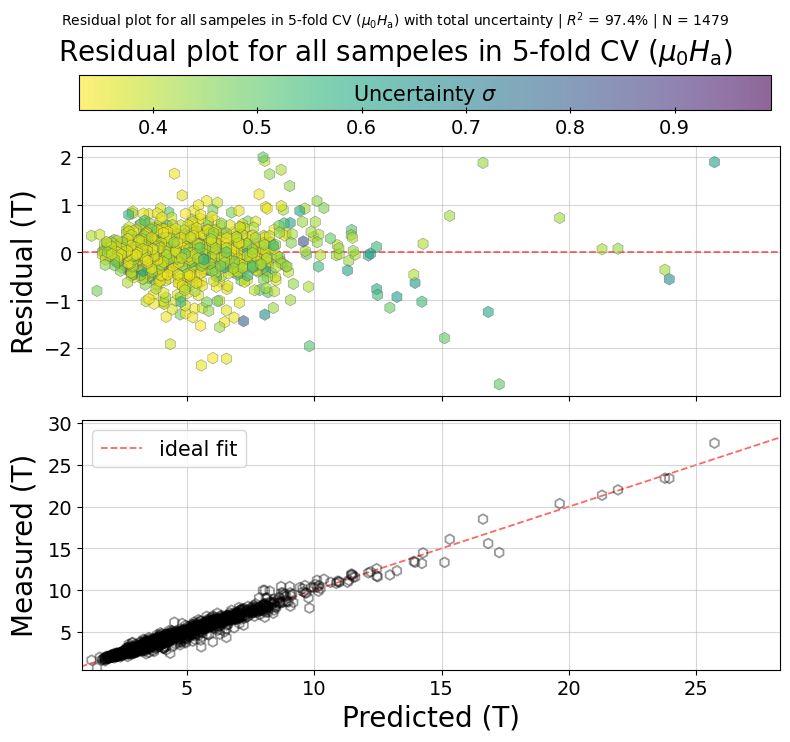

Saved to dir /home/wager/projects/PUBLICATION/magnetic-uncertainty/models/Ha_gpr/2026-01-19__20-00-43


In [79]:
title = f"Residual plot for all sampeles in 5-fold CV ({symbol})"
plot_cv_predictions_color_std(y_pred_cv_all, y, y_std_cv_all, 
                              title=title, 
                              details=title+' with total uncertainty',     
                              filename='Ha_all_samples_total_unc', 
                              dirname=MODEL_SAVE_PATH)

## The Confidence Curve

### Randomly seeded confidence curve

Fixed random seed: 123
Trial 1/10: fitting ...
Fixed random seed: 124
Trial 2/10: fitting ...
Fixed random seed: 125
Trial 3/10: fitting ...
Fixed random seed: 126
Trial 4/10: fitting ...
Fixed random seed: 127
Trial 5/10: fitting ...
Fixed random seed: 128
Trial 6/10: fitting ...
Fixed random seed: 129
Trial 7/10: fitting ...
Fixed random seed: 130
Trial 8/10: fitting ...
Fixed random seed: 131
Trial 9/10: fitting ...
Fixed random seed: 132
Trial 10/10: fitting ...


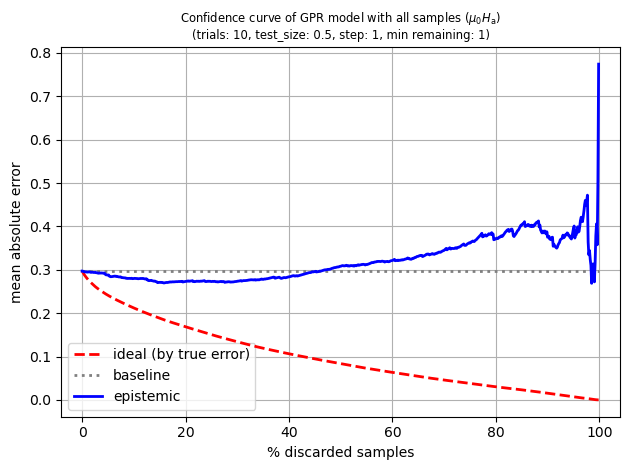

Saved to file: /home/wager/projects/PUBLICATION/magnetic-uncertainty/models/Ha_gpr/2026-01-19__20-00-43/confidence_curve_Ha_all_samples.png


In [80]:
plot_confidence(
    regressor=regressor,
    df=df_ha,
    features=features_physics,
    label="Ha",
    output_dir=MODEL_SAVE_PATH,
    plot_name=f"confidence_curve_Ha_all_samples",
    title=f"Confidence curve of GPR model with all samples ({symbol})",
    seed=SEED,
    metric="mae",
    n_trials=10,
    test_size=0.5,
    plot_std_total_only=True,
    min_remaining=1,
    step=1
)